In [1965]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import random

In [1966]:
df = pd.read_csv('datasets/mall-customers.csv')

In [1967]:
print(f"Rows: {df.shape[0]}\nColumns: {df.shape[1]}")

Rows: 200
Columns: 7


In [1968]:
df.head()

,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
0,1,M,19,High School,Married,15,39
1,2,M,21,Graduate,Single,15,81
2,3,F,20,Graduate,Married,16,6
3,4,F,23,High School,Unknown,16,77
4,5,F,31,Uneducated,Married,17,40


In [1969]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Education                 0
Marital Status            0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [1970]:
df.duplicated().sum()

0

In [1971]:
# Make a numerical copy of the dataset

df_num = df.select_dtypes(include='number').copy()

In [1972]:
df_num.skew()

CustomerID                0.000000
Age                       0.485569
Annual Income (k$)        0.321843
Spending Score (1-100)   -0.047220
dtype: float64

**NOTE: No need to log transform**

## Section I: Preprocessing

In [1973]:
# Extract X

X = df.copy()
X.drop('CustomerID', axis=1, inplace=True)

X.head()

,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
0,M,19,High School,Married,15,39
1,M,21,Graduate,Single,15,81
2,F,20,Graduate,Married,16,6
3,F,23,High School,Unknown,16,77
4,F,31,Uneducated,Married,17,40


In [1974]:
# Rename 'Annual Income (k$)' to a more systematic name and transform X accordingly

X.rename(columns={'Annual Income (k$)':'AnnualIncome', 'Marital Status':'MaritalStatus', 'Education ': 'Education', 
    'Spending Score (1-100)': 'SpendingScore'}, inplace=True)
X['AnnualIncome'] *= 1000
X.head()

,Gender,Age,Education,MaritalStatus,AnnualIncome,SpendingScore
0,M,19,High School,Married,15000,39
1,M,21,Graduate,Single,15000,81
2,F,20,Graduate,Married,16000,6
3,F,23,High School,Unknown,16000,77
4,F,31,Uneducated,Married,17000,40


In [1975]:
# See the unique values for Education

temp = X['Education'].value_counts()

temp.head(10)

Education
Graduate         67
High School      40
Uneducated       31
Unknown          26
College          17
Doctorate        11
Post-Graduate     8
Name: count, dtype: int64

In [1976]:
# Save copy of X before encoding

X_cpy = X.copy()

X_cpy.head()

,Gender,Age,Education,MaritalStatus,AnnualIncome,SpendingScore
0,M,19,High School,Married,15000,39
1,M,21,Graduate,Single,15000,81
2,F,20,Graduate,Married,16000,6
3,F,23,High School,Unknown,16000,77
4,F,31,Uneducated,Married,17000,40


In [1977]:
# Encode the datatset

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

one_hot_cols = ['Gender', 'MaritalStatus']

for col in one_hot_cols:
    ohe = OneHotEncoder(sparse_output=False).set_output(transform='pandas')
    transformed_cols = ohe.fit_transform(X[[col]])
    X.drop(col, axis=1, inplace=True)
    X = pd.concat([X, transformed_cols], axis=1)

oe = OrdinalEncoder(categories=[[
    'Uneducated', 'Unknown', 'High School', 
    'College', 'Graduate', 'Post-Graduate', 'Doctorate'
]])

X[['Education']] = oe.fit_transform(X[['Education']])

annual_income = X['AnnualIncome'].copy()
X.drop('AnnualIncome', axis=1, inplace=True)

X = pd.concat([X, annual_income], axis=1)

X.head()

,Age,Education,SpendingScore,Gender_F,Gender_M,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Unknown,AnnualIncome
0,19,2.0,39,0.0,1.0,0.0,1.0,0.0,0.0,15000
1,21,4.0,81,0.0,1.0,0.0,0.0,1.0,0.0,15000
2,20,4.0,6,1.0,0.0,0.0,1.0,0.0,0.0,16000
3,23,2.0,77,1.0,0.0,0.0,0.0,0.0,1.0,16000
4,31,0.0,40,1.0,0.0,0.0,1.0,0.0,0.0,17000


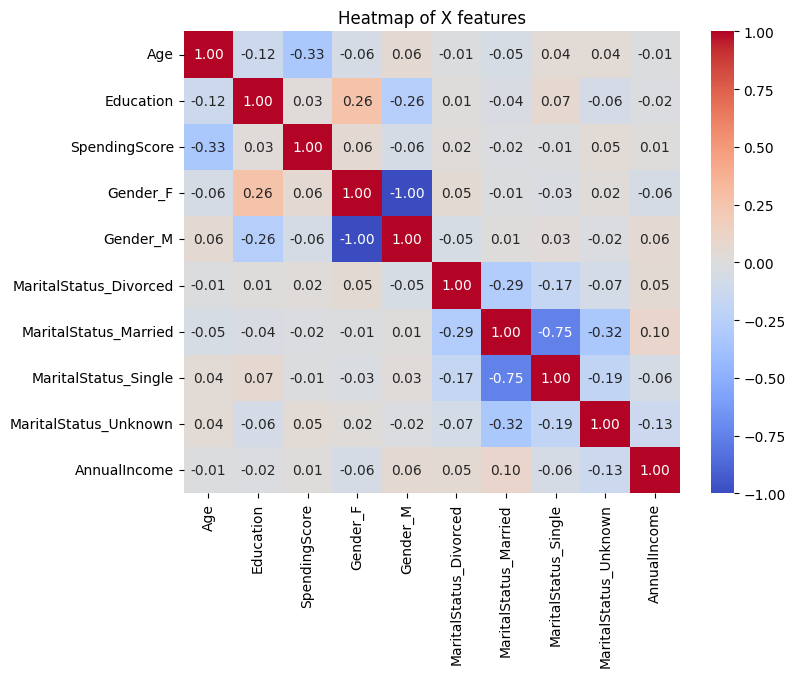

In [1978]:
# Heatmap for possible colinearity

_corr = X.corr()

plt.figure(figsize=(8, 6))
plt.title('Heatmap of X features')
sns.heatmap(data=_corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

**NOTE: There doesn't seem to be any major colinearities**

In [1979]:
# Scale the dataset

from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
X_scaled = ss.fit_transform(X)

In [1980]:
# Custom hierarchical clustering implementation - still need to fix

def euclidean_distance(f1: np.ndarray, f2: np.ndarray):
    return math.sqrt(np.sum((f1 - f2)** 2))


def custom_hierarchical_clustering(data: np.ndarray):
    data = list(data.copy())

    while len(data) > 1:                 
        all_distances_pairs = {}

        for idx, s in enumerate(data):
            other = [(j, sample) for j, sample in enumerate(data) if j != idx]

            distances = [euclidean_distance(s, sample) for _, sample in other]

            min_idx = np.argmin(distances)

            nearest_idx = other[min_idx][0]

            all_distances_pairs[(idx, nearest_idx)] = distances[min_idx]

        (s1_idx, s2_idx) = min(all_distances_pairs, key=all_distances_pairs.get)

        s1 = data[s1_idx]
        s2 = data[s2_idx]

        cluster = np.vstack((s1, s2))

        for i in sorted([s1_idx, s2_idx], reverse=True):
            data.pop(i)

        data.append(cluster)
    return data

test_data = pd.DataFrame({'F1': [1, 2, 1, 17], 'F2': [2, 6, 2.2, 2], 'F3': [4, 9, 5, 3]})
test_data_values = test_data.values

test_cluster = custom_hierarchical_clustering(test_data_values)

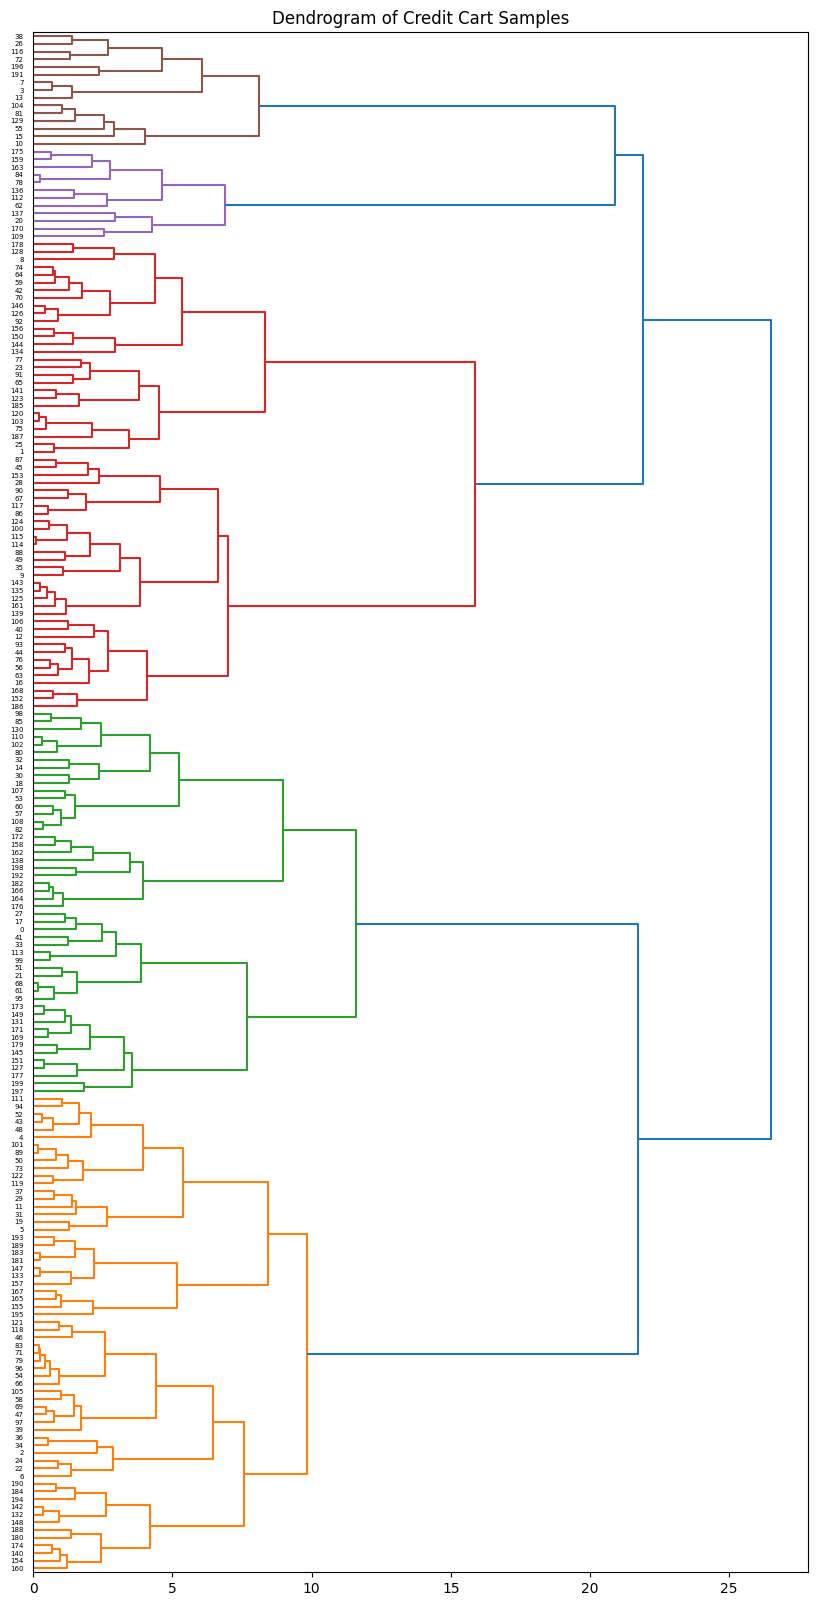

In [1981]:
from scipy.cluster.hierarchy import linkage, dendrogram


Z = linkage(X_scaled, method='ward', metric='euclidean')

plt.figure(figsize=(10, 20))
plt.title('Dendrogram of Credit Cart Samples')
dendrogram(Z, orientation='right', show_leaf_counts=True)
plt.show()

In [1982]:
from scipy.cluster.hierarchy import fcluster
from sklearn.metrics import silhouette_score

max_score = -math.inf
optimal_cluster = None

for t in range(2, 11):
    labels = fcluster(Z, t=t, criterion='maxclust')
    sil = silhouette_score(X_scaled, labels)

    if sil > max_score:
        max_score = sil
        optimal_cluster = t

print(f"Optimal cluster size: {optimal_cluster}")
print(f"Optimal silhouette score: {max_score:.2f}")

Optimal cluster size: 6
Optimal silhouette score: 0.33


In [1983]:
# Split the dendogram to incorporate 5 clusters 
labels = fcluster(Z, t=optimal_cluster, criterion='maxclust')

X_ref = X.copy()
X = X_cpy
X['Cluster'] = labels

X.head()

,Gender,Age,Education,MaritalStatus,AnnualIncome,SpendingScore,Cluster
0,M,19,High School,Married,15000,39,2
1,M,21,Graduate,Single,15000,81,4
2,F,20,Graduate,Married,16000,6,1
3,F,23,High School,Unknown,16000,77,6
4,F,31,Uneducated,Married,17000,40,1


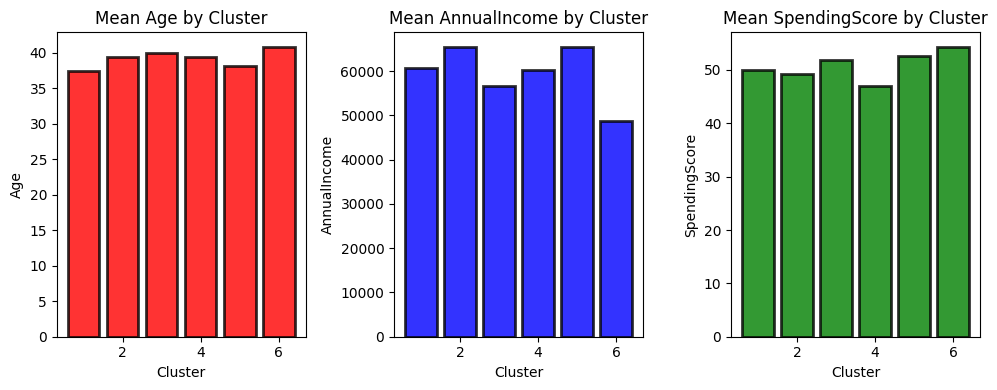

In [1984]:
# Bar charts per cluster for the numerical features

metrics = X.iloc[:, :-1].columns
colors = ['red', 'blue', 'green', 'orange', 'steelblue', 'purple']

fig, ax = plt.subplots(1, 3, figsize=(10, 4))

for idx, metric in enumerate(['Age', 'AnnualIncome', 'SpendingScore']):
    selected_metric_by_cluster = X.groupby("Cluster")[metric].mean()
    ax[idx].set_title(f"Mean {metric} by Cluster")

    ax[idx].bar(selected_metric_by_cluster.index, selected_metric_by_cluster.values, 
        color=colors[idx], linewidth=2, edgecolor='black', alpha=0.8)
    ax[idx].set_xlabel('Cluster')
    ax[idx].set_ylabel(metric)

plt.tight_layout()
plt.show()


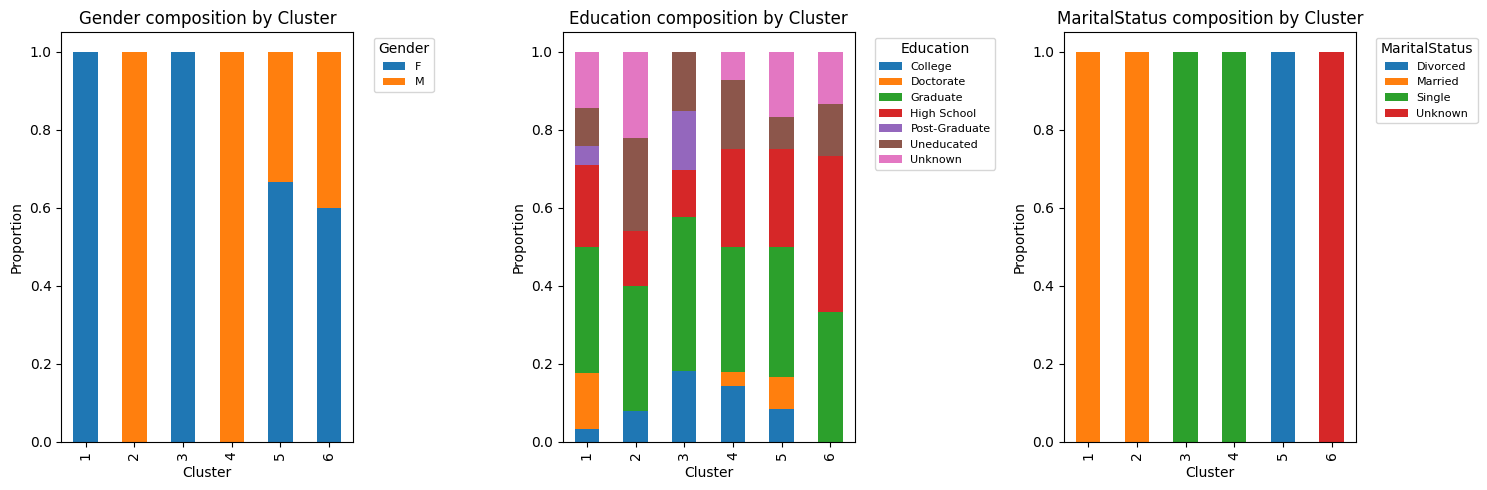

In [1985]:
# Stacked bar charts for the categorical features

cat_cols = ['Gender', 'Education', 'MaritalStatus']

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

for idx, col in enumerate(cat_cols):
    props = X.groupby('Cluster')[col].value_counts(normalize=True).unstack().fillna(0)
    props.plot(kind='bar', stacked=True, ax=ax[idx], legend=True)
    ax[idx].set_title(f'{col} composition by Cluster')
    ax[idx].set_xlabel('Cluster')
    ax[idx].set_ylabel('Proportion')
    ax[idx].legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

(200, 2)


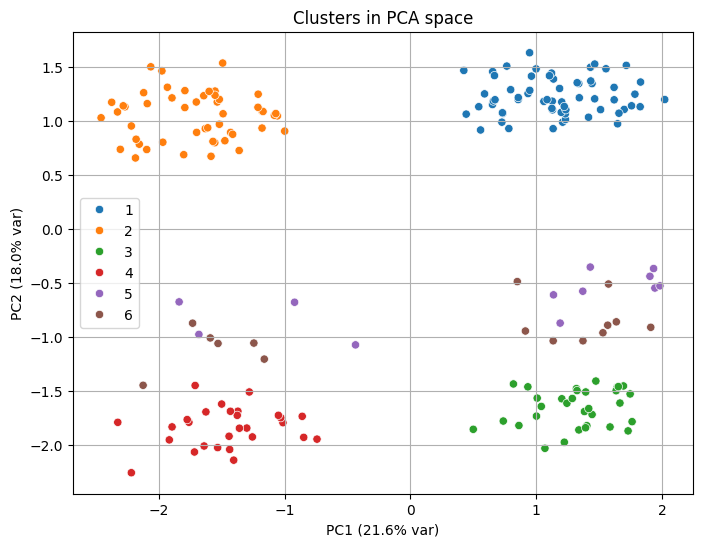

In [1986]:
# Plotting the clusters in 2D

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(X_pca.shape)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels, palette='tab10')
plt.title('Clusters in PCA space')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
plt.grid(True)
plt.show()

**NOTE: Clusters 5 and 6 didn't cluster well - there is significant overlap between the two**

In [1987]:
# See loadings 

loadings = pd.DataFrame(pca.components_, index=['PC1', 'PC2'], columns=X_ref.columns)
loadings.head()

,Age,Education,SpendingScore,Gender_F,Gender_M,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Unknown,AnnualIncome
PC1,-0.129594,0.312980,0.112074,0.654366,-0.654366,0.077989,-0.064542,0.013772,0.027243,-0.071546
PC2,-0.101423,-0.030167,0.030012,0.053452,-0.053452,-0.090487,0.719067,-0.641969,-0.151404,0.147974
